# Laboratorio en Clase 2: Métricas en Clasificación Multiclase con PyTorch
Este laboratorio se centra en entrenar y evaluar una red neuronal multiclase para diagnóstico clínico, reforzando la interpretación correcta de métricas.

## Objetivo
Entrenar un modelo multiclase robusto y analizar su desempeño con métricas clave (Accuracy, Matriz de Confusión, Precision, Recall, F1-Score y ROC-AUC), explicando qué mide cada una, su fórmula y para qué sirve en la toma de decisiones.

## Estudiantes
- Valencia Medina Freddy Daniel
- Tarqui Mita Kevin Rolando

## Dataset
- mening missing 12.csv

## Contexto de la consigna académica
Trabajo desarrollado en grupo de dos estudiantes para clasificación multiclase con PyTorch, usando un dataset de clasificación del primer parcial.

**Consigna cubierta en este notebook:**
- Construcción de red neuronal multiclase.
- Aplicación de técnicas de regularización.
- Aplicación de técnicas de optimización.
- Evaluación con métricas y explicación de resultados.

**Dataset elegido del primer parcial:** `mening missing 12.csv` (objetivo: `Diagnosis`).

In [4]:
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    roc_auc_score,
    f1_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    top_k_accuracy_score
    )
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

## 1. Carga y Preprocesamiento de Datos
En esta etapa se limpian nulos, se codifican variables categóricas y se normalizan características.

Para mejorar generalización y controlar overfitting, se realiza división estratificada en tres subconjuntos:
- Entrenamiento (`train`)
- Validación (`val`)
- Prueba (`test`)

Esto evita evaluar durante el entrenamiento sobre el conjunto de prueba final.

In [5]:
def load_and_preprocess_data(filepath, test_size=0.2, val_size=0.2, random_state=42):
    # Cargar datos
    df = pd.read_csv(filepath)
    
    # Manejo de valores nulos
    for col in df.select_dtypes(include=np.number).columns:
        df[col] = df[col].fillna(df[col].median())
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].fillna(df[col].mode()[0])
        
    # Columna objetivo
    target_column = 'Diagnosis'
    
    X = df.drop(columns=['Patient_ID', target_column])
    y = df[target_column]
    
    # One-Hot Encoding en variables categóricas
    X = pd.get_dummies(X, drop_first=True)
    
    # Label Encoding para objetivo multiclase
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    
    # 1) Separar test final
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y_encoded, test_size=test_size, random_state=random_state, stratify=y_encoded
    )
    
    # 2) Separar validación desde trainval
    val_relative_size = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval,
        y_trainval,
        test_size=val_relative_size,
        random_state=random_state,
        stratify=y_trainval,
    )
    
    # Escalado
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)
    
    # Tensores
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    X_val = torch.tensor(X_val, dtype=torch.float32)
    y_val = torch.tensor(y_val, dtype=torch.long)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.long)
    
    return X_train, X_val, X_test, y_train, y_val, y_test, label_encoder.classes_, X.shape[1]

## 2. Definir Dataset y Modelo (PyTorch)
Se define un modelo MLP con regularización explícita contra overfitting:
- `BatchNorm1d` para estabilizar distribuciones internas.
- `Dropout` para reducir dependencia excesiva entre neuronas.
- Capacidad moderada para evitar memorizar ruido del dataset.

In [6]:
class MedicalDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def build_model(input_dim, num_classes):
    model = nn.Sequential(
        nn.Linear(input_dim, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(128, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.35),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Dropout(0.25),
        nn.Linear(32, num_classes),
    )
    return model

## 3. Función de Entrenamiento y Validación
Se incorporan estrategias para reducir overfitting durante el entrenamiento:
- `weight_decay` (regularización L2 en el optimizador Adam).
- `ReduceLROnPlateau` (reduce el learning rate cuando la validación se estanca).
- `Early Stopping` (detiene entrenamiento cuando no mejora la pérdida de validación).
- Restauración automática del mejor modelo según validación.

In [7]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=300,
    lr=0.001,
    weight_decay=1e-4,
    patience=30,
    min_delta=1e-4,
    device='cpu',
):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=8
    )
    
    model.to(device)
    
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 0
    wait = 0
    
    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()
        
        train_loss = running_train_loss / len(train_loader)
        train_losses.append(train_loss)
        
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
        
        val_loss = running_val_loss / len(val_loader)
        val_losses.append(val_loss)
        scheduler.step(val_loss)
        
        if val_loss < (best_val_loss - min_delta):
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            wait = 0
        else:
            wait += 1
        
        if (epoch + 1) % 10 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(
                f'Epoch [{epoch+1}/{epochs}] - '
                f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f}'
            )
        
        if wait >= patience:
            print(f'Early stopping en época {epoch+1}. Mejor época: {best_epoch}.')
            break
    
    model.load_state_dict(best_state)
    print(f'Modelo restaurado desde la mejor época: {best_epoch} con Val Loss: {best_val_loss:.4f}')
    
    return model, train_losses, val_losses, best_epoch, best_val_loss

### 3.1. Regularización aplicada: qué es, para qué sirve y por qué se eligió
En este proyecto se aplican varias técnicas de regularización para reducir overfitting y mejorar generalización en datos no vistos.

**Técnicas usadas:**
- `Dropout` en capas ocultas: desactiva neuronas aleatoriamente durante entrenamiento.
- `weight_decay` en Adam: regularización L2 que penaliza pesos excesivos.
- `Early Stopping`: detiene entrenamiento cuando la pérdida de validación deja de mejorar.
- `BatchNorm`: estabiliza activaciones internas y mejora robustez.

**Fórmula de regularización L2:**
`Loss_total = Loss_CE + \lambda * ||w||_2^2`

**Para qué sirve en este modelo:**
- Evita que la red memorice ruido del conjunto de entrenamiento.
- Reduce la brecha entre pérdida de entrenamiento y validación.
- Mantiene un modelo más estable para evaluar en test clínico.

**Por qué se optó por estas técnicas:**
- Son efectivas y estándar en MLP tabular con PyTorch.
- Son compatibles entre sí y no complican la implementación del flujo.
- Permiten mejorar generalización sin cambiar el objetivo del problema.

### 3.2. Optimización aplicada: qué es, para qué sirve y por qué se eligió
La optimización define cómo actualizamos pesos para minimizar la función de pérdida.

**Estrategia usada:**
- Optimizador `Adam` con `lr=0.001` y `weight_decay=1e-4`.
- Scheduler `ReduceLROnPlateau` para reducir tasa de aprendizaje cuando validación se estanca.

**Actualización base (idea de descenso por gradiente):**
`w_{t+1} = w_t - \eta \nabla_w L`

**Para qué sirve en este modelo:**
- Adam acelera convergencia inicial y maneja mejor escalas distintas entre variables.
- El scheduler permite refinar el aprendizaje al acercarse a mínimos.
- Reduce oscilaciones y favorece una validación más estable.

**Por qué se optó por esta estrategia:**
- Buena relación entre simplicidad y rendimiento para datasets tabulares multiclase.
- Menor sensibilidad al ajuste manual que alternativas más básicas.
- Combina bien con early stopping para evitar entrenamientos innecesarios.

## 4. Ejecución del Flujo de Trabajo
Aquí se ejecuta el pipeline completo con prevención de overfitting:
- Carga y separación `train/val/test`.
- Entrenamiento con regularización y parada temprana.
- Conservación del conjunto de prueba para evaluación final.

In [8]:
# Rutas sugeridas
local_filepath = "/home/kayser/Downloads/LABORATORIO EN CLASE/mening missing 12.csv"
kaggle_filepath = "/kaggle/input/datasets/freddyvalenciamedina/mening-missing/mening missing 12.csv"

filepath = local_filepath if os.path.exists(local_filepath) else kaggle_filepath
print(f"Dataset seleccionado: {filepath}")

# Preprocesamiento con división train/val/test
X_train, X_val, X_test, y_train, y_val, y_test, class_names, input_dim = load_and_preprocess_data(filepath)
num_classes = len(class_names)
print(f"Dimensiones de entrada: {input_dim}, Clases ({num_classes}): {class_names}")

# DataLoaders
train_dataset = MedicalDataset(X_train, y_train)
val_dataset = MedicalDataset(X_val, y_val)
test_dataset = MedicalDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Inicializar modelo y entrenar
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = build_model(input_dim, num_classes)

print("\nIniciando entrenamiento con control de overfitting...")
model, train_losses, val_losses, best_epoch, best_val_loss = train_model(
    model,
    train_loader,
    val_loader,
    epochs=300,
    lr=0.001,
    weight_decay=1e-4,
    patience=30,
    min_delta=1e-4,
    device=device,
    )

print(f"Mejor época: {best_epoch} | Mejor Val Loss: {best_val_loss:.4f}")

Dataset seleccionado: /kaggle/input/datasets/freddyvalenciamedina/mening-missing/mening missing 12.csv
Dimensiones de entrada: 13, Clases (3): ['Bacterial' 'Unknown' 'Viral']

Iniciando entrenamiento con control de overfitting...
Epoch [10/300] - Train Loss: 0.4024 | Val Loss: 0.3680 | LR: 0.001000
Epoch [20/300] - Train Loss: 0.3891 | Val Loss: 0.3515 | LR: 0.001000
Epoch [30/300] - Train Loss: 0.3358 | Val Loss: 0.3620 | LR: 0.000500
Epoch [40/300] - Train Loss: 0.3302 | Val Loss: 0.3657 | LR: 0.000250
Epoch [50/300] - Train Loss: 0.3286 | Val Loss: 0.3653 | LR: 0.000125
Early stopping en época 50. Mejor época: 20.
Modelo restaurado desde la mejor época: 20 con Val Loss: 0.3515
Mejor época: 20 | Mejor Val Loss: 0.3515


## 5. Evaluación Inicial: Curva de Aprendizaje y Overfitting
La curva de aprendizaje compara la pérdida en entrenamiento y validación por época.

**Qué muestra:**
- Si ambas pérdidas bajan de forma parecida, el modelo generaliza mejor.
- Si `train loss` baja pero `val loss` sube o se estanca, hay sobreajuste.

**Indicador útil de sobreajuste:**
- Brecha de generalización: `Gap = ValLoss - TrainLoss`.
- Un gap creciente durante muchas épocas suele indicar overfitting.

**Para qué sirve:**
- Decidir cuándo detener entrenamiento (early stopping).
- Ajustar regularización (dropout, L2, arquitectura, learning rate).

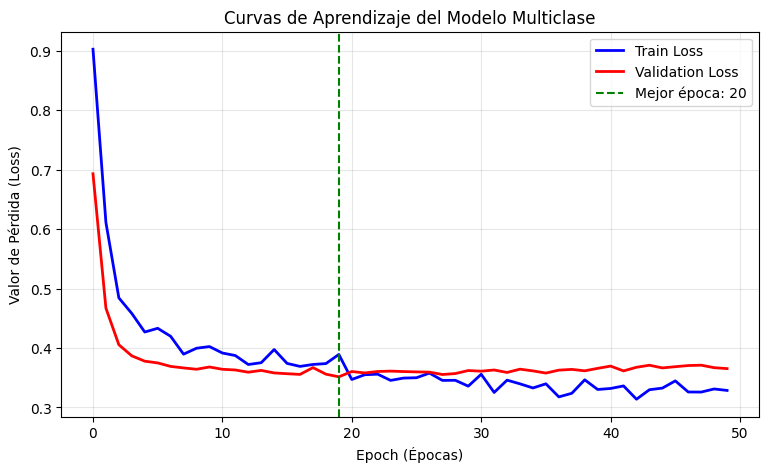

Gap final (Val - Train): 0.0367


In [9]:
plt.figure(figsize=(9, 5))
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='red', linewidth=2)
plt.axvline(best_epoch - 1, color='green', linestyle='--', label=f'Mejor época: {best_epoch}')
plt.xlabel('Epoch (Épocas)')
plt.ylabel('Valor de Pérdida (Loss)')
plt.legend()
plt.title('Curvas de Aprendizaje del Modelo Multiclase')
plt.grid(True, alpha=0.3)
plt.show()

if len(train_losses) == len(val_losses):
    gap = np.array(val_losses) - np.array(train_losses)
    print(f'Gap final (Val - Train): {gap[-1]:.4f}')

## 6. Generación de Predicciones
Antes de calcular métricas, generamos predicciones sobre el conjunto de prueba.

**Qué muestra:**
- La clase estimada por el modelo para cada paciente.

**Para qué sirve:**
- Construir todas las métricas posteriores (accuracy, matriz, precision, recall, F1, ROC-AUC).
- Mantener evaluación justa sobre datos no usados en entrenamiento.

In [10]:
model.eval()
with torch.no_grad():
    outputs = model(X_test.to(device))
    _, predicted = torch.max(outputs, 1)

y_true = y_test.numpy()
y_pred = predicted.cpu().numpy()

print(f"Total de pacientes evaluados en test: {len(y_pred)}")

Total de pacientes evaluados en test: 240


### 6.1. Métrica de Exactitud (Accuracy General)
**Fórmula:** `Accuracy = (TP + TN) / (TP + TN + FP + FN)`
En multiclase, equivale al porcentaje de predicciones correctas sobre el total.

**Qué muestra:**
- Proporción global de aciertos del modelo.

**Para qué sirve:**
- Obtener una lectura rápida del rendimiento general.
- Comparar modelos de manera preliminar.

**Limitación importante:**
- Puede ocultar errores en clases minoritarias (desbalance de clases).

In [11]:
accuracy = accuracy_score(y_true, y_pred)
print(f'Accuracy General del Modelo: {accuracy * 100:.2f}%')

Accuracy General del Modelo: 77.50%


### 6.2. Matriz de Confusión Multiclase
La matriz resume conteos por clase real (filas) vs clase predicha (columnas).

**Qué muestra:**
- Aciertos por clase en la diagonal principal.
- Confusiones entre clases fuera de la diagonal.

**Relación con fórmulas por clase i:**
- `Precision_i = TP_i / (TP_i + FP_i)`
- `Recall_i = TP_i / (TP_i + FN_i)`

**Para qué sirve:**
- Detectar exactamente qué clases se confunden entre sí.
- Guiar mejoras del modelo o del balanceo del dataset.

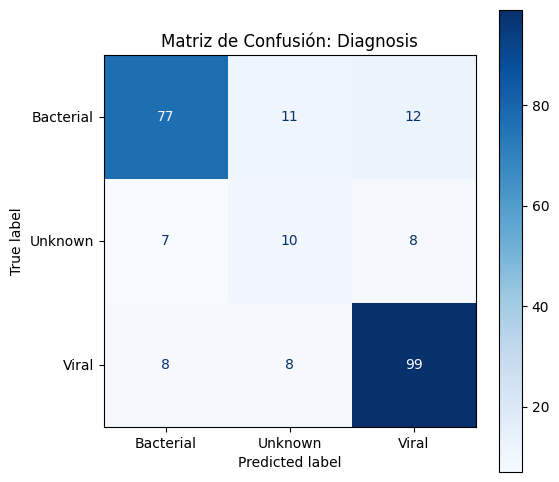

In [12]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[str(c) for c in class_names])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusión: Diagnosis')
plt.show()

### 6.3. Reporte de Clasificación (Precision, Recall y F1-Score)
Estas métricas se calculan por clase y luego se resumen con promedios (`macro`, `weighted`).

**Fórmulas clave:**
- `Precision = TP / (TP + FP)`
- `Recall = TP / (TP + FN)`
- `F1 = 2 * (Precision * Recall) / (Precision + Recall)`

**Qué muestra:**
- `Precision`: qué tan confiable es una clase cuando el modelo la predice.
- `Recall`: qué tantos casos reales de una clase logra detectar.
- `F1`: equilibrio entre precision y recall.

**Para qué sirve:**
- Priorizar métricas según el contexto (por ejemplo, en salud suele importar no perder casos: alto recall).

In [13]:
report = classification_report(y_true, y_pred, target_names=[str(c) for c in class_names])
print('================ REPORTE DE CLASIFICACIÓN MULTICLASE ================')
print(report)

macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')
macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
bal_acc = balanced_accuracy_score(y_true, y_pred)

print(f'Macro Precision: {macro_precision:.4f}')
print(f'Macro Recall: {macro_recall:.4f}')
print(f'Macro F1: {macro_f1:.4f}')
print(f'Weighted F1: {weighted_f1:.4f}')
print(f'Balanced Accuracy: {bal_acc:.4f}')

================ REPORTE DE CLASIFICACIÓN MULTICLASE ================
              precision    recall  f1-score   support

   Bacterial       0.84      0.77      0.80       100
     Unknown       0.34      0.40      0.37        25
       Viral       0.83      0.86      0.85       115

    accuracy                           0.78       240
   macro avg       0.67      0.68      0.67       240
weighted avg       0.78      0.78      0.78       240

Macro Precision: 0.6712
Macro Recall: 0.6770
Macro F1: 0.6729
Weighted F1: 0.7782
Balanced Accuracy: 0.6770


### 6.4. Gráficas por Clase (Precision, Recall, F1)
Visualizamos el desempeño por categoría para identificar fortalezas y debilidades.

**Qué muestra:**
- Comparación directa entre métricas por cada diagnóstico.

**Para qué sirve:**
- Detectar clases donde el modelo falla más.
- Definir acciones: más datos de esa clase, ajuste de pesos, cambio de arquitectura o umbrales.

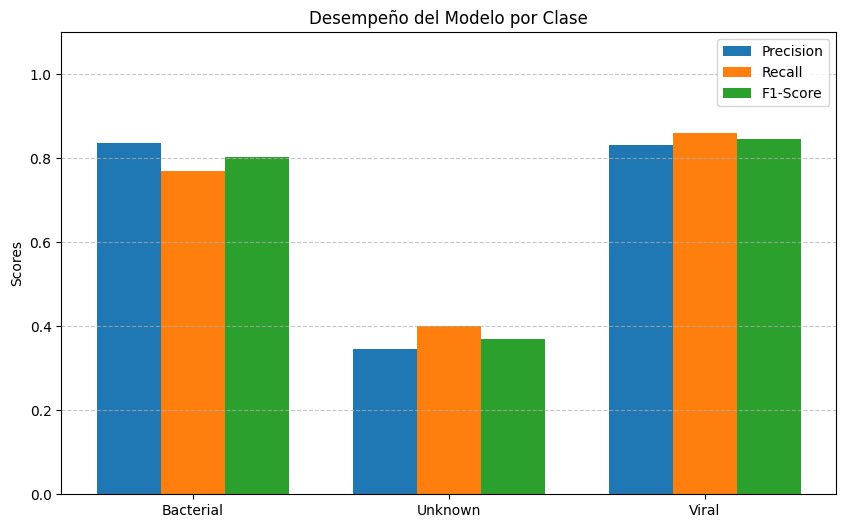

In [14]:
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, precision, width, label='Precision', color='#1f77b4')
ax.bar(x, recall, width, label='Recall', color='#ff7f0e')
ax.bar(x + width, f1, width, label='F1-Score', color='#2ca02c')

ax.set_ylabel('Scores')
ax.set_title('Desempeño del Modelo por Clase')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.legend()

plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 6.5. Curva ROC Multiclase (One-vs-Rest) y AUC
La curva ROC compara sensibilidad y tasa de falsos positivos para distintos umbrales de decisión.

**Fórmulas:**
- `TPR (Recall) = TP / (TP + FN)`
- `FPR = FP / (FP + TN)`
- `AUC = área bajo la curva ROC`

**Qué muestra:**
- Capacidad de separación entre cada clase y el resto.
- Mientras más se acerque la curva a la esquina superior izquierda, mejor.

**Para qué sirve:**
- Evaluar calidad del ranking probabilístico del modelo.
- Comparar modelos incluso cuando cambia el umbral de clasificación.

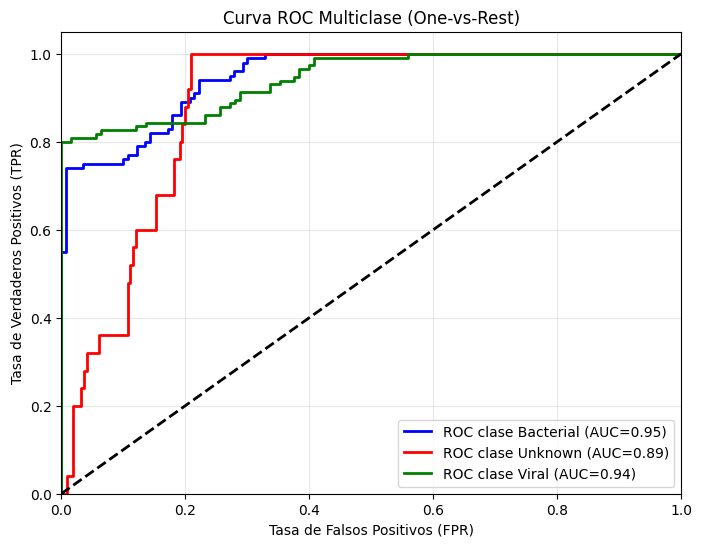

AUC Macro (OvR): 0.9267
AUC Weighted (OvR): 0.9399


In [15]:
# 1) Obtener probabilidades con Softmax
model.eval()
with torch.no_grad():
    outputs = model(X_test.to(device))
    probs = torch.softmax(outputs, dim=1).cpu().numpy()

# 2) Binarizar etiquetas verdaderas para esquema One-vs-Rest
classes_idx = list(range(len(class_names)))
y_test_bin = label_binarize(y_test.numpy(), classes=classes_idx)
n_classes = y_test_bin.shape[1]

# 3) Curvas ROC y AUC por clase
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4) AUC global (macro y weighted)
macro_auc_ovr = roc_auc_score(y_test_bin, probs, average='macro', multi_class='ovr')
weighted_auc_ovr = roc_auc_score(y_test_bin, probs, average='weighted', multi_class='ovr')

# 5) Graficar
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']
for i in range(n_classes):
    color = colors[i % len(colors)]
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f'ROC clase {class_names[i]} (AUC={roc_auc[i]:.2f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC Multiclase (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f'AUC Macro (OvR): {macro_auc_ovr:.4f}')
print(f'AUC Weighted (OvR): {weighted_auc_ovr:.4f}')

## 7. Niveles de precisión alcanzados e interpretación
En esta celda se resume el nivel de precisión logrado por el modelo en test.

**Qué reporta:**
- Accuracy general.
- Balanced Accuracy (útil con posible desbalance).
- F1 macro y weighted.
- Top-2 Accuracy (si la clase correcta está entre las 2 probabilidades más altas).

**Para qué sirve:**
- Comunicar resultados finales de manera ejecutiva.
- Justificar el desempeño del modelo frente a la consigna del laboratorio.

In [16]:
# Resumen cuantitativo final en test
acc = accuracy_score(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

# Top-k accuracy usando probabilidades del modelo
k_eval = 2 if len(class_names) >= 2 else 1
topk_acc = top_k_accuracy_score(
    y_true, probs, k=k_eval, labels=np.arange(len(class_names))
    )

print('================ RESUMEN FINAL DE MÉTRICAS ================')
print(f'Accuracy: {acc:.4f} ({acc*100:.2f}%)')
print(f'Balanced Accuracy: {bal_acc:.4f} ({bal_acc*100:.2f}%)')
print(f'F1 Macro: {macro_f1:.4f}')
print(f'F1 Weighted: {weighted_f1:.4f}')
print(f'Top-{k_eval} Accuracy: {topk_acc:.4f} ({topk_acc*100:.2f}%)')

if acc >= 0.90:
    print('Interpretación: desempeño alto para clasificación clínica multiclase.')
elif acc >= 0.80:
    print('Interpretación: desempeño bueno, con margen de mejora por clase.')
elif acc >= 0.70:
    print('Interpretación: desempeño aceptable, revisar clases con mayor confusión.')
else:
    print('Interpretación: desempeño bajo, requiere más ajuste de features/modelo.')

================ RESUMEN FINAL DE MÉTRICAS ================
Accuracy: 0.7750 (77.50%)
Balanced Accuracy: 0.6770 (67.70%)
F1 Macro: 0.6729
F1 Weighted: 0.7782
Top-2 Accuracy: 0.8792 (87.92%)
Interpretación: desempeño aceptable, revisar clases con mayor confusión.
